# Pineapple Cup Detection — Inference Walkthrough

This notebook runs the **trained model** on sample images and visualises the results.

![Grid overview](docs/grid_overview.png)

---

## What this system does

Given a photo of a 3×3 bookshelf, it tells you:
- **Is the pineapple cup in the photo?**
- **Which shelf cell is it in?**

The 9 cells are numbered like this:

```
| 0 | 1 | 2 |   ← top row
| 3 | 4 | 5 |   ← middle row
| 6 | 7 | 8 |   ← bottom row
```

Output example:
```json
{ "has_cup": 1, "cell_id": 4 }
```

> **Prerequisites**: model weights must exist at `runs/detect/runs/train/pineapple_cup_v1/weights/best.pt`.  
> Run `python src/augment.py` then `python src/train.py` from the project root to generate them.

---
## Step 0 — Setup

In [1]:
import sys
from pathlib import Path

# Add src/ to path so we can import detect and evaluate
sys.path.insert(0, str(Path("src").resolve()))

WEIGHTS = "runs/detect/runs/train/pineapple_cup_v1/weights/best.pt"

if not Path(WEIGHTS).exists():
    print(f"Weights not found at {WEIGHTS}")
    print("Run: python src/augment.py && python src/train.py")
else:
    print(f"Weights found: {WEIGHTS}")

Weights found: runs/detect/runs/train/pineapple_cup_v1/weights/best.pt


---
## Step 1 — Detect the cup in a single image

Change `test_image` to try different images.

In [2]:
import json
from detect import Detector

test_image = "sample_data/top_left.png"   # change to any image

detector = Detector(WEIGHTS)
result = detector.detect(test_image)

CELL_NAMES = [
    "top-left",    "top-center",    "top-right",
    "middle-left", "middle-center", "middle-right",
    "bottom-left", "bottom-center", "bottom-right",
]

print(f"Image : {test_image}")
print(f"Result: {json.dumps(result, indent=2)}")

if result["has_cup"]:
    print(f"\nCup found in cell {result['cell_id']} ({CELL_NAMES[result['cell_id']]})")
else:
    print("\nNo cup detected")

Image : sample_data/top_left.png
Result: {
  "has_cup": 1,
  "cell_id": 0
}

Cup found in cell 0 (top-left)


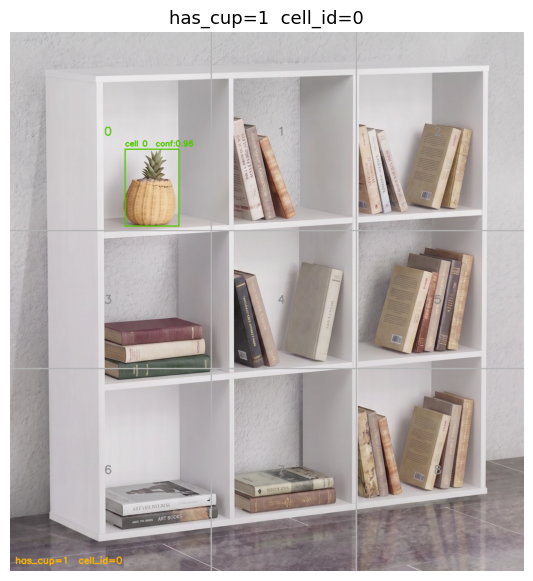

In [3]:
import cv2
import matplotlib.pyplot as plt

result, annotated_bgr = detector.detect_with_viz(test_image)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 7))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title(f"has_cup={result['has_cup']}  cell_id={result['cell_id']}", fontsize=13)
plt.show()

---
## Step 2 — Evaluate on all 10 sample images

| Metric | Meaning |
|---|---|
| Presence accuracy | How often does it correctly say cup / no cup? |
| Cell accuracy | How often does it pick the right shelf cell? |
| End-to-end accuracy | Both presence AND cell correct |

In [4]:
from evaluate import evaluate

metrics = evaluate(WEIGHTS, data_dir="sample_data", save_viz=True)


Image                          GT                Pred         Presence    Cell  
--------------------------------------------------------------------------------


bottom_center             has=1 cell=7       has=1 cell=7        ✓         ✓    


bottom_left               has=1 cell=6       has=1 cell=6        ✓         ✓    


bottom_right              has=1 cell=8       has=1 cell=8        ✓         ✓    


middle_center             has=1 cell=4       has=1 cell=4        ✓         ✓    


...

missing                 has=0 cell=None    has=0 cell=None       ✓        N/A   


top_center                has=1 cell=1       has=1 cell=1        ✓         ✓    


top_left                  has=1 cell=0       has=1 cell=0        ✓         ✓    


top_right                 has=1 cell=2       has=1 cell=2        ✓         ✓    
--------------------------------------------------------------------------------

Presence accuracy : 10/10 (100.0%)
Cell accuracy     : 9/9 (100.0%)


End-to-end accuracy: 10/10 (100.0%)

Annotated images saved to eval_viz/


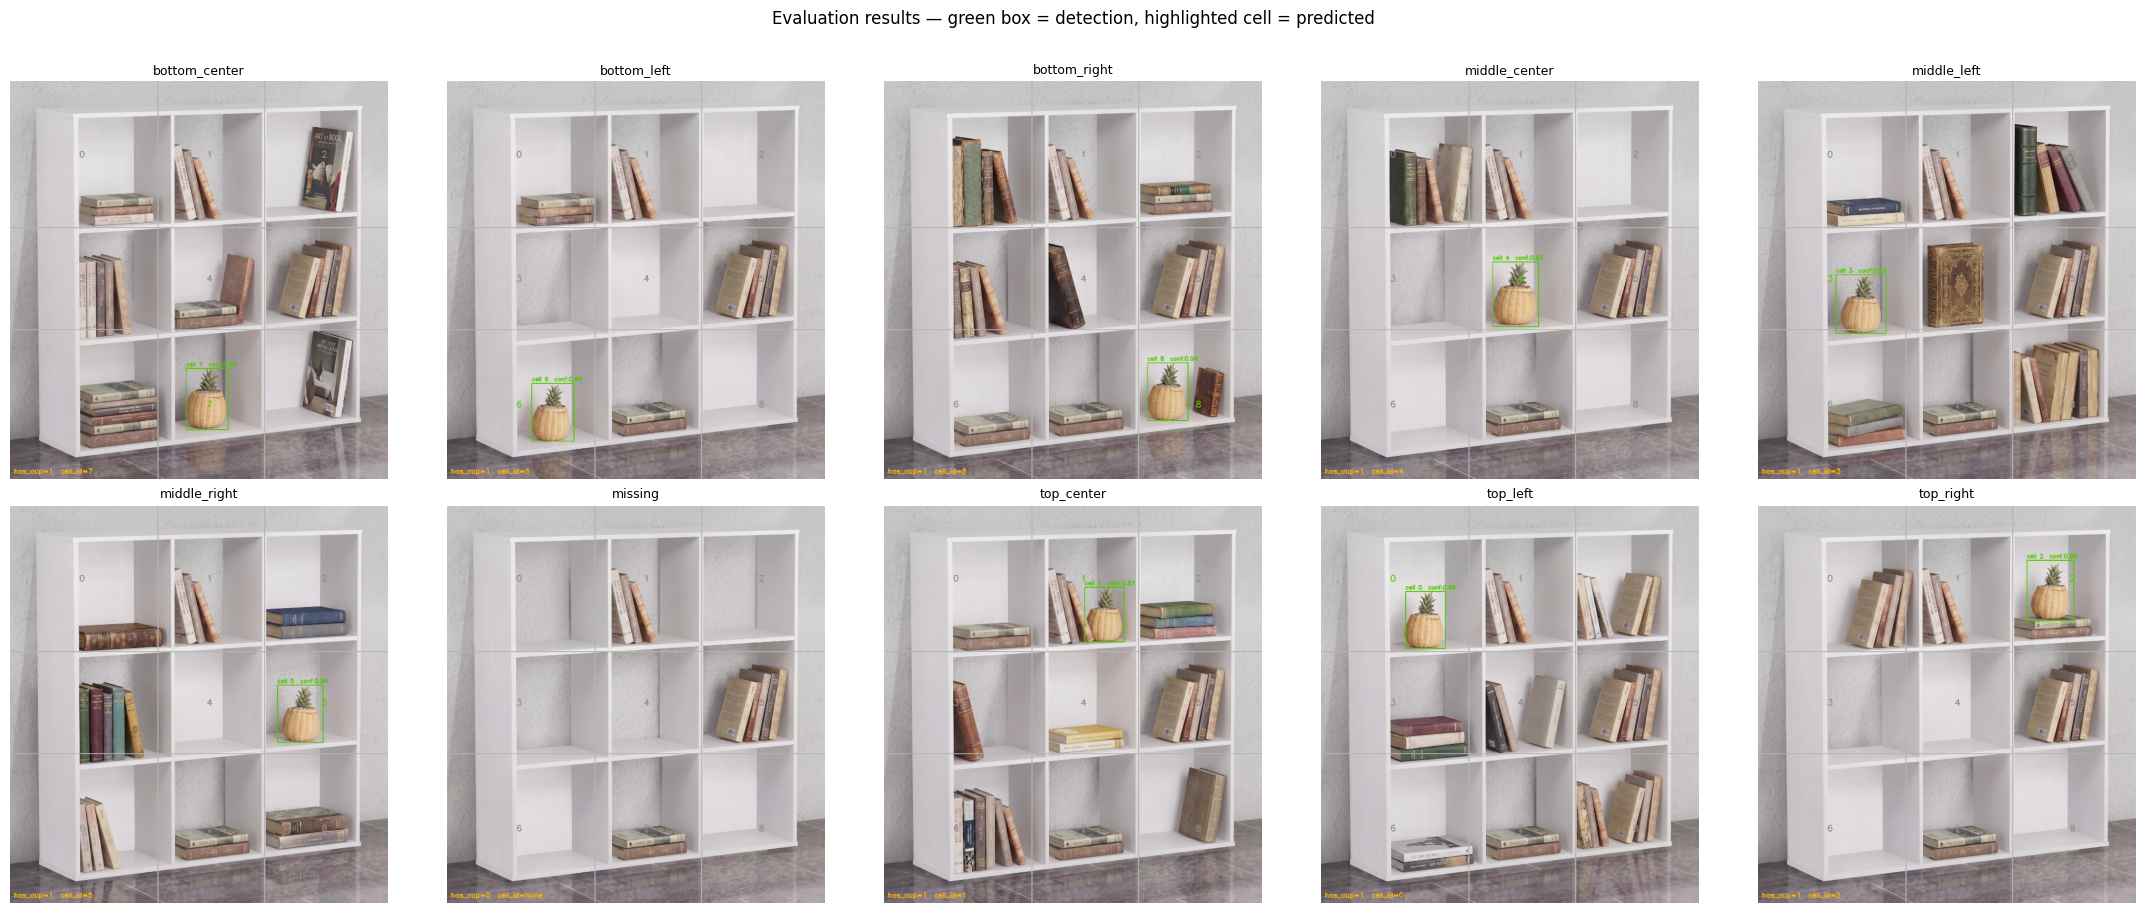

In [5]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

viz_images = sorted(Path("eval_viz").glob("*.png"))

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for ax, p in zip(axes, viz_images):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(p.stem.replace("_eval", ""), fontsize=9)
    ax.axis("off")

plt.suptitle("Evaluation results — green box = detection, highlighted cell = predicted", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

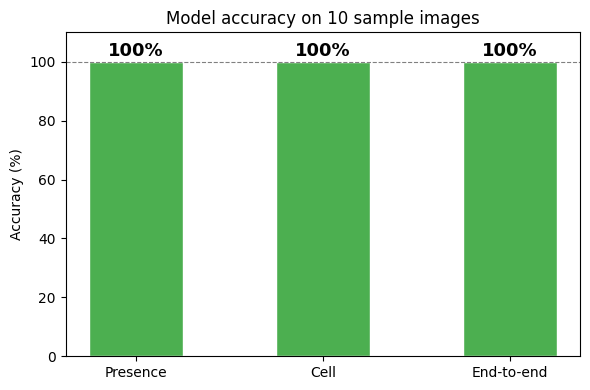

In [6]:
import matplotlib.pyplot as plt

labels = ["Presence", "Cell", "End-to-end"]
values = [
    metrics["presence_accuracy"] * 100,
    metrics["cell_accuracy"] * 100,
    metrics["end_to_end_accuracy"] * 100,
]
colors = ["#4CAF50" if v == 100 else "#FF9800" for v in values]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model accuracy on 10 sample images")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.0f}%", ha="center", fontsize=13, fontweight="bold")
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()